Pregunta 1. 
Leer el archivo Retail_Invoices.xlsx y realizar un análisis de calidad de datos, para
definir la calidad de la data entregada considerando valores anómalos, valores
faltantes, etc. Limpia lo que sea necesario y realiza un análisis exploratorio de los
datos considerando gráficos de distribuciones y correlaciones entre estos.


In [2]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carga de datos
df = pd.read_excel('Retail_Invoices.xlsx')

print(f'Dimensiones del dataset: {df.shape}')
df.head()

Dimensiones del dataset: (22190, 6)


,InvoiceNo,InvoiceDate,CustomerID,Quantity,price_total,StockCode
0,536365,2010-12-01,17850,40,139.12,7
1,536366,2010-12-01,17850,12,22.20,2
2,536367,2010-12-01,13047,83,278.73,12
3,536368,2010-12-01,13047,15,70.05,4
4,536369,2010-12-01,13047,3,17.85,1


In [3]:
# Información general de tipos de datos
print('=== Información general ===')
df.info()

=== Información general ===
<class 'pandas.DataFrame'>
RangeIndex: 22190 entries, 0 to 22189
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    22190 non-null  object        
 1   InvoiceDate  22190 non-null  datetime64[us]
 2   CustomerID   22190 non-null  int64         
 3   Quantity     22190 non-null  int64         
 4   price_total  22190 non-null  float64       
 5   StockCode    22190 non-null  int64         
dtypes: datetime64[us](1), float64(1), int64(3), object(1)
memory usage: 1.0+ MB


In [5]:
# Valores nulos por columna
print('=== Valores nulos por columna ===')
print(df.isnull().sum())

=== Valores nulos por columna ===
InvoiceNo      0
InvoiceDate    0
CustomerID     0
Quantity       0
price_total    0
StockCode      0
dtype: int64


In [4]:
# Estadísticas descriptivas
print('=== Estadísticas descriptivas ===')
df.describe()

=== Estadísticas descriptivas ===


,InvoiceDate,CustomerID,Quantity,price_total,StockCode
count,22190,22190.000000,22190.000000,22190.000000,22190.000000
mean,2011-06-29 05:59:15.223073,15238.498738,221.130599,374.045327,18.333889
min,2010-12-01 00:00:00,12346.000000,-80995.000000,-168469.600000,1.000000
25%,2011-03-29 00:00:00,13755.000000,30.000000,87.962500,3.000000
50%,2011-07-08 00:00:00,15136.000000,120.000000,241.505000,12.000000
75%,2011-10-10 00:00:00,16746.000000,254.000000,418.022500,24.000000
max,2011-12-09 00:00:00,18287.000000,80995.000000,168469.600000,542.000000
std,NaN,1733.149624,1170.215301,2018.482869,23.892111


In [6]:
# Verificación de boletas duplicadas
print(f'Filas totales: {len(df)}')
print(f'InvoiceNo únicos: {df["InvoiceNo"].nunique()}')

Filas totales: 22190
InvoiceNo únicos: 22190


In [7]:
# Detección de valores anómalos: cantidades y montos negativos
negativos_qty = (df['Quantity'] < 0).sum()
negativos_price = (df['price_total'] < 0).sum()
ceros_price = (df['price_total'] == 0).sum()

print(f'Filas con Quantity negativo: {negativos_qty}')
print(f'Filas con price_total negativo: {negativos_price}')
print(f'Filas con price_total igual a cero: {ceros_price}')

Filas con Quantity negativo: 3654
Filas con price_total negativo: 3654
Filas con price_total igual a cero: 4


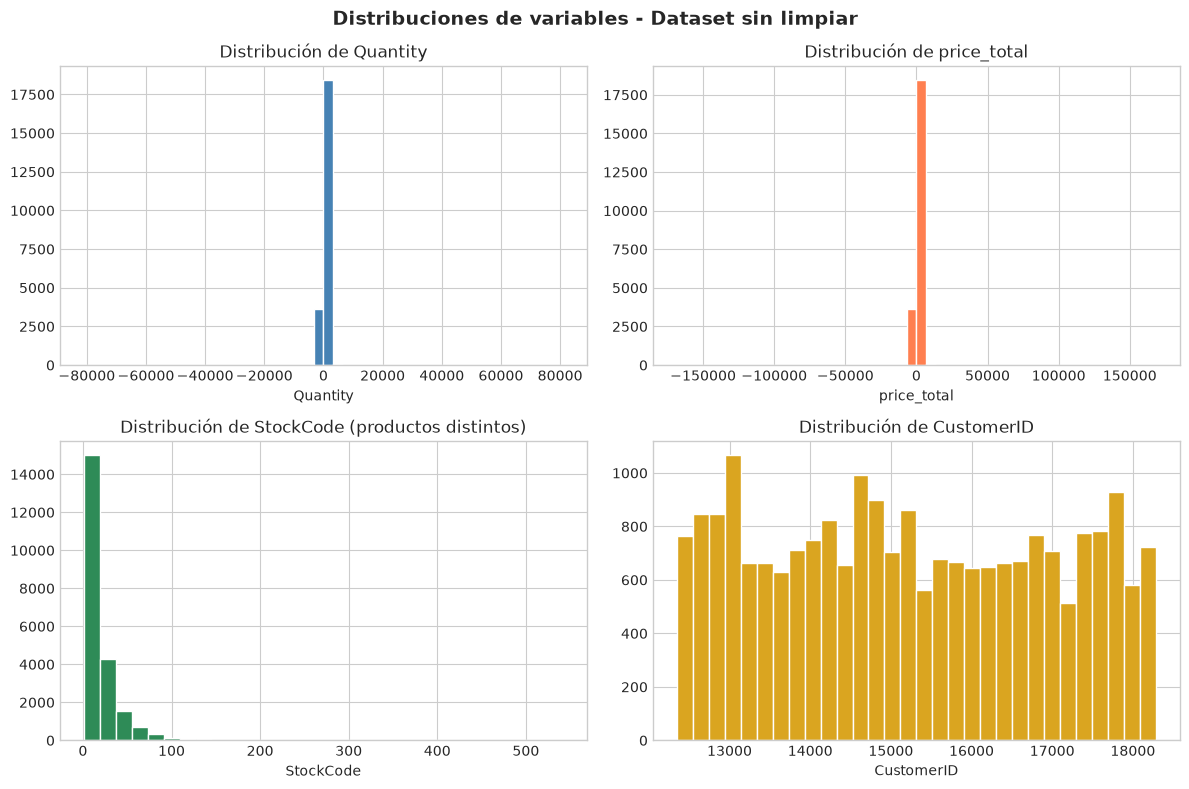

In [8]:
# Distribución de las variables numéricas
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0,0].hist(df['Quantity'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribución de Quantity')
axes[0,0].set_xlabel('Quantity')

axes[0,1].hist(df['price_total'], bins=50, color='coral', edgecolor='white')
axes[0,1].set_title('Distribución de price_total')
axes[0,1].set_xlabel('price_total')

axes[1,0].hist(df['StockCode'], bins=30, color='seagreen', edgecolor='white')
axes[1,0].set_title('Distribución de StockCode (productos distintos)')
axes[1,0].set_xlabel('StockCode')

axes[1,1].hist(df['CustomerID'], bins=30, color='goldenrod', edgecolor='white')
axes[1,1].set_title('Distribución de CustomerID')
axes[1,1].set_xlabel('CustomerID')

plt.suptitle('Distribuciones de variables - Dataset sin limpiar', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

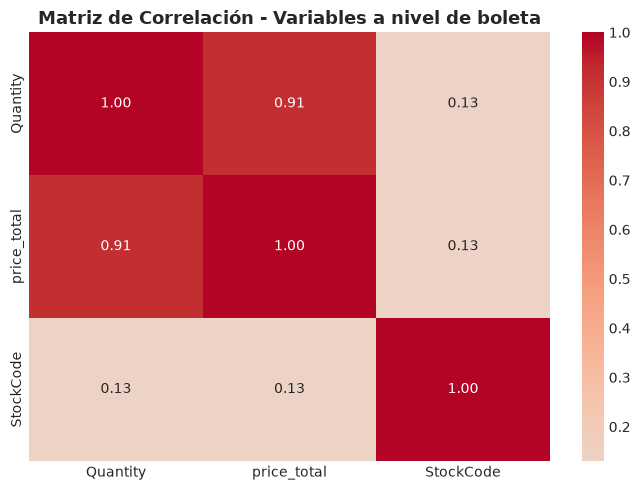

In [9]:
# Matriz de correlación entre variables numéricas
variables_numericas = ['Quantity', 'price_total', 'StockCode']

fig, ax = plt.subplots(figsize=(7, 5))
corr_matrix = df[variables_numericas].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    ax=ax
)
ax.set_title('Matriz de Correlación - Variables a nivel de boleta', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
# Inspección del valor extremo detectado en el describe()
print('Boleta con Quantity más negativo:')
print(df.loc[df['Quantity'].idxmin()])
print()
print('Boleta con Quantity más positivo:')
print(df.loc[df['Quantity'].idxmax()])

Boleta con Quantity más negativo:
InvoiceNo                  C581484
InvoiceDate    2011-12-09 00:00:00
CustomerID                   16446
Quantity                    -80995
price_total              -168469.6
StockCode                        1
Name: 22185, dtype: object

Boleta con Quantity más positivo:
InvoiceNo                   581483
InvoiceDate    2011-12-09 00:00:00
CustomerID                   16446
Quantity                     80995
price_total               168469.6
StockCode                        1
Name: 18503, dtype: object


In [11]:
# Verificar si las devoluciones se identifican por el prefijo 'C' en InvoiceNo
df['es_cancelacion'] = df['InvoiceNo'].astype(str).str.startswith('C')

print('Boletas marcadas con prefijo C:', df['es_cancelacion'].sum())
print('Boletas con Quantity negativo:', (df['Quantity'] < 0).sum())
print()
print('¿Coinciden exactamente ambos criterios?')
print((df['es_cancelacion'] == (df['Quantity'] < 0)).all())

Boletas marcadas con prefijo C: 3654
Boletas con Quantity negativo: 3654

¿Coinciden exactamente ambos criterios?
True


In [12]:
# Limpieza de datos
print(f'Filas antes de limpiar: {len(df)}')

# 1. Eliminar cancelaciones/devoluciones (InvoiceNo con prefijo 'C')
df_clean = df[~df['es_cancelacion']].copy()
df_clean = df_clean.drop(columns=['es_cancelacion'])

# 2. Eliminar boletas con price_total igual a cero (no representan una transacción real)
df_clean = df_clean[df_clean['price_total'] > 0]

print(f'Filas después de limpiar: {len(df_clean)}')
print(f'Filas eliminadas: {len(df) - len(df_clean)}')

Filas antes de limpiar: 22190
Filas después de limpiar: 18532
Filas eliminadas: 3658


2. Generar variables para la segmentación. Notar que la granularidad de la data es por
boleta y se necesita segmentar clientes, por lo que es necesario generar variables a
nivel de clientes. Se propone generar al menos RFM (Recencia, frecuencia y monto).

In [13]:
# Definir fecha de referencia para calcular recencia
fecha_referencia = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f'Fecha de referencia: {fecha_referencia}')

Fecha de referencia: 2011-12-10 00:00:00


In [14]:
# Construcción de variables RFM a nivel de cliente
rfm = df_clean.groupby('CustomerID').agg(
    recencia=('InvoiceDate', lambda x: (fecha_referencia - x.max()).days),
    frecuencia=('InvoiceNo', 'nunique'),
    monto=('price_total', 'sum')
).reset_index()

print(f'Número de clientes únicos: {len(rfm)}')
rfm.head()

Número de clientes únicos: 4338


,CustomerID,recencia,frecuencia,monto
0,12346,326,1,77183.60
1,12347,3,7,4310.00
2,12348,76,4,1797.24
3,12349,19,1,1757.55
4,12350,311,1,334.40


3. Realizar un análisis exploratorio y las transformaciones necesarias a las nuevas
variables.

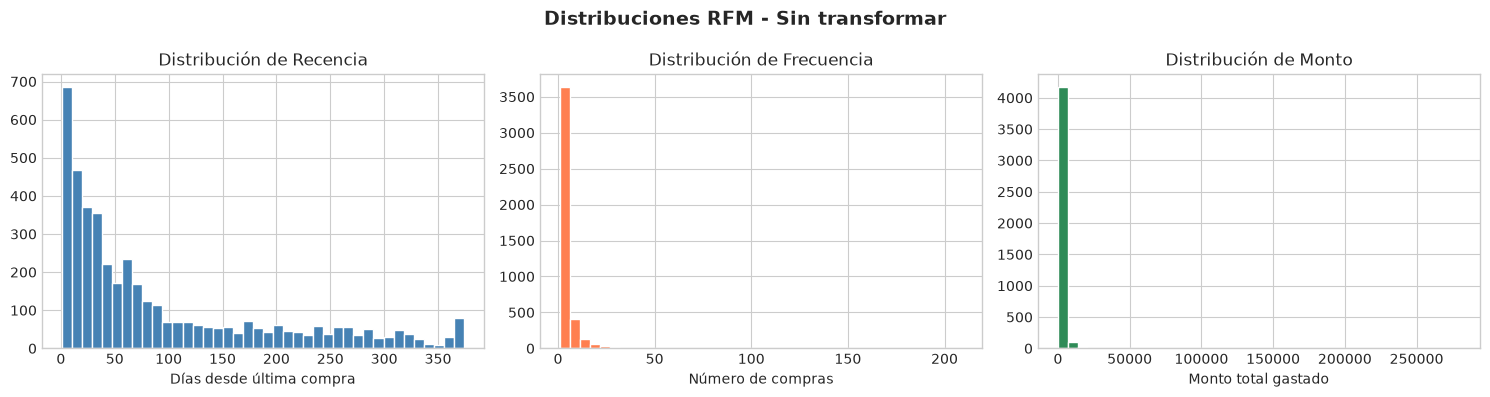

In [15]:
# Distribuciones de las variables RFM antes de transformar
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(rfm['recencia'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Recencia')
axes[0].set_xlabel('Días desde última compra')

axes[1].hist(rfm['frecuencia'], bins=40, color='coral', edgecolor='white')
axes[1].set_title('Distribución de Frecuencia')
axes[1].set_xlabel('Número de compras')

axes[2].hist(rfm['monto'], bins=40, color='seagreen', edgecolor='white')
axes[2].set_title('Distribución de Monto')
axes[2].set_xlabel('Monto total gastado')

plt.suptitle('Distribuciones RFM - Sin transformar', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Lectura del gráfico
Recencia se ve razonable — tiene una distribución sesgada pero manejable, con la mayoría de clientes concentrados en los primeros 100 días y una cola larga hacia 350+. No es ideal, pero no es un problema grave.
Frecuencia está extremadamente sesgada — casi todos los clientes están aplastados en una sola barra cerca de 0-10 compras, pero el eje se extiende hasta 200 porque debe existir al menos un cliente con frecuencia altísima (200+ compras) que "estira" toda la escala.
Monto tiene el mismo problema, aún más extremo — toda la masa de clientes está comprimida cerca de cero, mientras el eje llega hasta 250,000+ por algún cliente con gasto extraordinario.

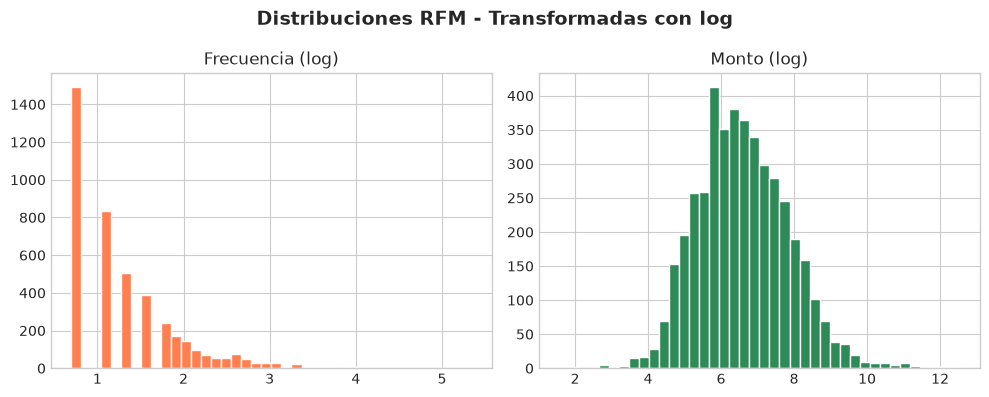

In [16]:
# Transformación logarítmica para reducir el sesgo en frecuencia y monto
rfm['frecuencia_log'] = np.log1p(rfm['frecuencia'])
rfm['monto_log'] = np.log1p(rfm['monto'])

# Comparar distribuciones transformadas
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(rfm['frecuencia_log'], bins=40, color='coral', edgecolor='white')
axes[0].set_title('Frecuencia (log)')

axes[1].hist(rfm['monto_log'], bins=40, color='seagreen', edgecolor='white')
axes[1].set_title('Monto (log)')

plt.suptitle('Distribuciones RFM - Transformadas con log', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
from sklearn.preprocessing import StandardScaler

# Seleccionar las variables finales para el clustering
variables_rfm = ['recencia', 'frecuencia_log', 'monto_log']
X_rfm = rfm[variables_rfm].copy()

# Estandarizar
scaler = StandardScaler()
X_rfm_scaled = scaler.fit_transform(X_rfm)

X_rfm_scaled = pd.DataFrame(X_rfm_scaled, columns=variables_rfm)
X_rfm_scaled.describe()

,recencia,frecuencia_log,monto_log
count,4.338000e+03,4.338000e+03,4.338000e+03
mean,-4.094875e-17,-7.206980e-17,1.375878e-16
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-9.205880e-01,-9.552143e-01,-4.004574e+00
25%,-7.505892e-01,-9.552143e-01,-6.856676e-01
50%,-4.205916e-01,-3.615828e-01,-6.218718e-02
75%,4.969016e-01,6.532370e-01,6.541861e-01
max,2.809385e+00,5.858535e+00,4.731591e+00


StandardScaler transforma cada variable para que tenga media 0 y desviación estándar 1 — así las tres quedan en la misma escala "neutral", sin que ninguna domine por tener números más grandes.

4. Aplicar al menos 2 algoritmos de clustering. Buscar el número indicado de clusters
que pueden tener y visualizar los cluster resultantes de los algoritmos.

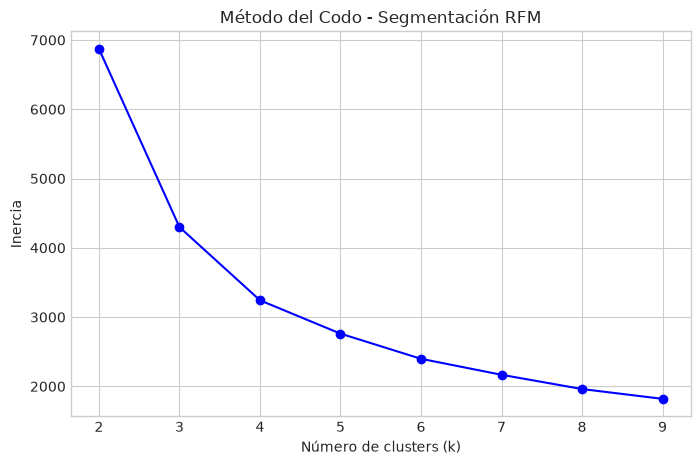

In [18]:
from sklearn.cluster import KMeans

# Método del codo para encontrar el K óptimo
k_values = range(2, 10)
inertia_values = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_rfm_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia_values, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo - Segmentación RFM')
plt.show()

El codo más razonable está en K=4, ya que es el último punto donde la mejora sigue siendo sustancial antes de que la curva se vuelva gradual. K=3 también es defendible, pero K=4 captura mejor el quiebre.

K=2 → Silhouette Score: 0.4064
K=3 → Silhouette Score: 0.4156
K=4 → Silhouette Score: 0.3795
K=5 → Silhouette Score: 0.3433
K=6 → Silhouette Score: 0.3299
K=7 → Silhouette Score: 0.2999
K=8 → Silhouette Score: 0.2999
K=9 → Silhouette Score: 0.2813


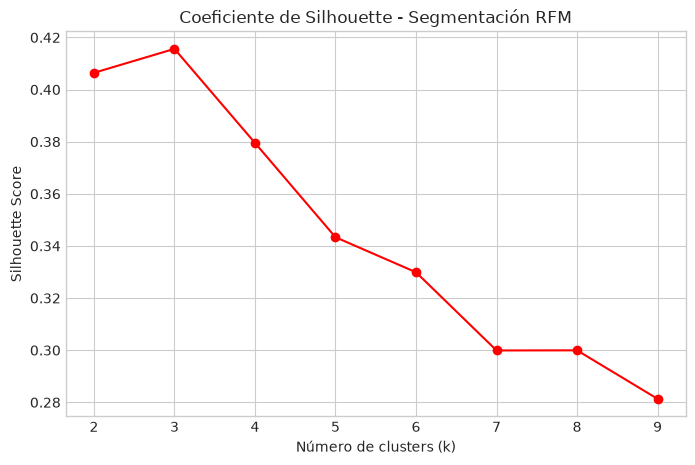

In [19]:
from sklearn.metrics import silhouette_score

# Calcular Silhouette Score para cada K
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_rfm_scaled)
    score = silhouette_score(X_rfm_scaled, labels)
    silhouette_scores.append(score)
    print(f'K={k} → Silhouette Score: {score:.4f}')

# Graficar
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, 'ro-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Coeficiente de Silhouette - Segmentación RFM')
plt.show()

el método del codo y el Silhouette Score no siempre coinciden exactamente, porque miden cosas distintas — el codo mide compacidad interna pura, mientras Silhouette también penaliza la separación entre clusters. Cuando hay conflicto entre ambos, conviene priorizar el Silhouette Score, porque es una métrica más completa (considera tanto cohesión como separación), mientras que la inercia siempre baja al aumentar K — incluso cuando los clusters extra no aportan separación real, por eso es más fácil que el codo "ilusione" con un K mayor al óptimo real. Quedaremos con k=3.

In [20]:
# Modelo final de K-means con K óptimo
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['cluster_kmeans'] = kmeans_final.fit_predict(X_rfm_scaled)

# Tamaño de cada cluster
print('Cantidad de clientes por cluster:')
print(rfm['cluster_kmeans'].value_counts().sort_index())

Cantidad de clientes por cluster:
cluster_kmeans
0    2033
1    1325
2     980
Name: count, dtype: int64


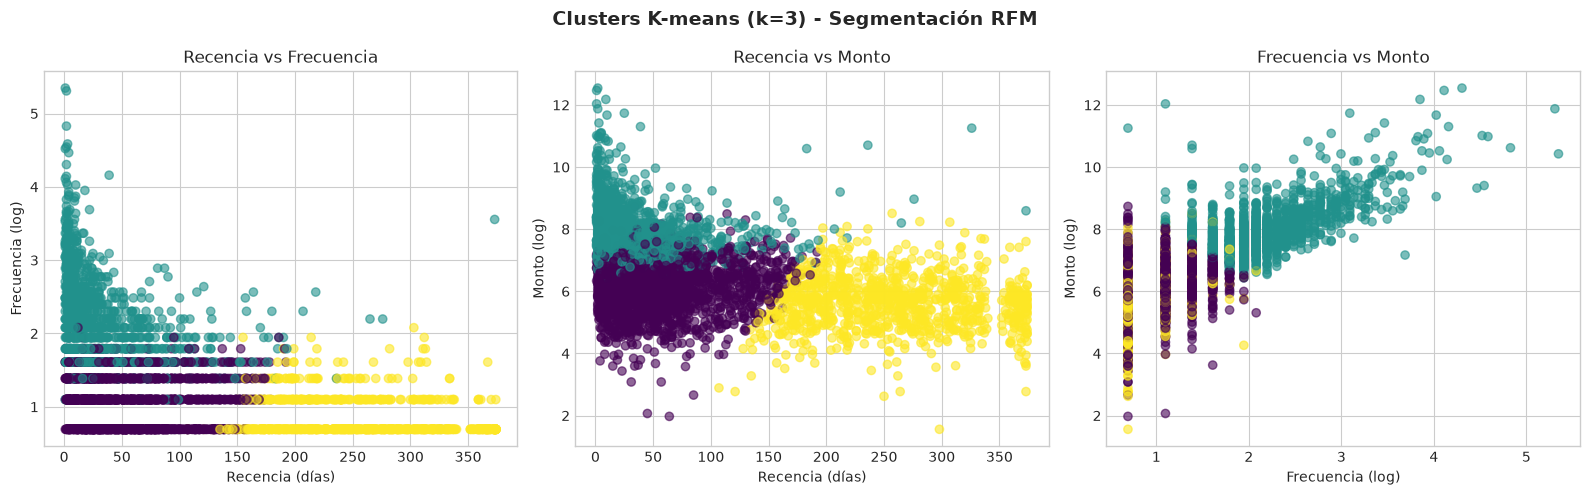

In [21]:
# Visualización de los clusters en pares de variables RFM
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

scatter1 = axes[0].scatter(rfm['recencia'], rfm['frecuencia_log'], 
                             c=rfm['cluster_kmeans'], cmap='viridis', alpha=0.6)
axes[0].set_xlabel('Recencia (días)')
axes[0].set_ylabel('Frecuencia (log)')
axes[0].set_title('Recencia vs Frecuencia')

axes[1].scatter(rfm['recencia'], rfm['monto_log'], 
                 c=rfm['cluster_kmeans'], cmap='viridis', alpha=0.6)
axes[1].set_xlabel('Recencia (días)')
axes[1].set_ylabel('Monto (log)')
axes[1].set_title('Recencia vs Monto')

axes[2].scatter(rfm['frecuencia_log'], rfm['monto_log'], 
                 c=rfm['cluster_kmeans'], cmap='viridis', alpha=0.6)
axes[2].set_xlabel('Frecuencia (log)')
axes[2].set_ylabel('Monto (log)')
axes[2].set_title('Frecuencia vs Monto')

plt.suptitle('Clusters K-means (k=3) - Segmentación RFM', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# Resumen estadístico por cluster (con valores originales, no transformados)
resumen_clusters = rfm.groupby('cluster_kmeans').agg(
    n_clientes=('CustomerID', 'count'),
    recencia_promedio=('recencia', 'mean'),
    frecuencia_promedio=('frecuencia', 'mean'),
    monto_promedio=('monto', 'mean'),
    monto_mediana=('monto', 'median')
).round(1)

resumen_clusters

,n_clientes,recencia_promedio,frecuencia_promedio,monto_promedio,monto_mediana
cluster_kmeans,,,,,
0,2033,55.3,2.0,614.5,508.8
1,1325,30.7,9.8,5488.1,2575.0
2,980,255.7,1.4,398.4,291.8


In [23]:
from sklearn.cluster import AgglomerativeClustering

# Clustering jerárquico con enlace Ward, mismo K=3 para poder comparar
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
rfm['cluster_jerarquico'] = hc.fit_predict(X_rfm_scaled)

# Tamaño de cada cluster
print('Cantidad de clientes por cluster (jerárquico):')
print(rfm['cluster_jerarquico'].value_counts().sort_index())

Cantidad de clientes por cluster (jerárquico):
cluster_jerarquico
0    2812
1    1028
2     498
Name: count, dtype: int64


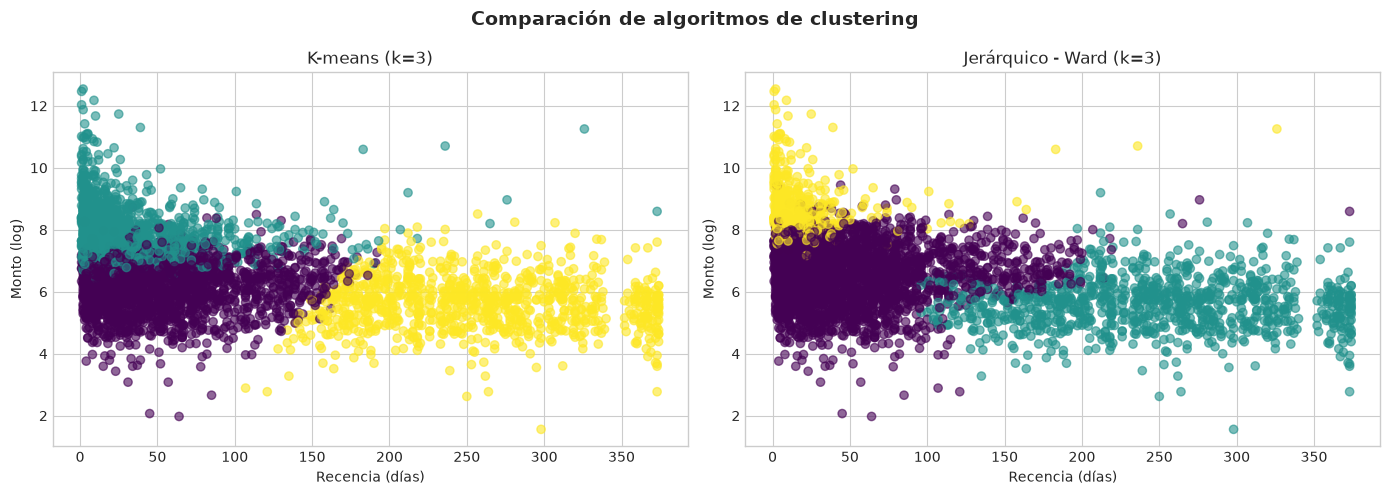

In [24]:
# Comparación visual: K-means vs Jerárquico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(rfm['recencia'], rfm['monto_log'], 
                 c=rfm['cluster_kmeans'], cmap='viridis', alpha=0.6)
axes[0].set_xlabel('Recencia (días)')
axes[0].set_ylabel('Monto (log)')
axes[0].set_title('K-means (k=3)')

axes[1].scatter(rfm['recencia'], rfm['monto_log'], 
                 c=rfm['cluster_jerarquico'], cmap='viridis', alpha=0.6)
axes[1].set_xlabel('Recencia (días)')
axes[1].set_ylabel('Monto (log)')
axes[1].set_title('Jerárquico - Ward (k=3)')

plt.suptitle('Comparación de algoritmos de clustering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

K-means dibuja sus fronteras principalmente a lo largo del eje Recencia — el amarillo es claramente "recencia alta" (la derecha completa del gráfico, sin importar cuánto gastaron), y el límite entre morado y teal corta verticalmente cerca del monto.

Jerárquico (Ward) dibuja sus fronteras de forma distinta — el amarillo aquí captura más bien "monto alto" (la parte de arriba del gráfico, sin importar tanto la recencia), y separa morado/teal más por una mezcla de ambas variables en una franja diagonal.

K-means en este caso prioriza la recencia como variable más discriminante; el jerárquico prioriza más el monto. Ninguno es "incorrecto" matemáticamente, pero llevan a decisiones de negocio distintas

5. Evaluar la calidad de los clustering de forma numérica y realizar una explicación de
cada segmento asignándoles un nombre descriptivo.


In [25]:
from sklearn.metrics import davies_bouldin_score

# Métricas de validación para ambos algoritmos
sil_kmeans = silhouette_score(X_rfm_scaled, rfm['cluster_kmeans'])
db_kmeans = davies_bouldin_score(X_rfm_scaled, rfm['cluster_kmeans'])

sil_jerarquico = silhouette_score(X_rfm_scaled, rfm['cluster_jerarquico'])
db_jerarquico = davies_bouldin_score(X_rfm_scaled, rfm['cluster_jerarquico'])

print('=== Comparación de métricas de validación ===')
print(f'{"Algoritmo":<15} {"Silhouette":>12} {"Davies-Bouldin":>16}')
print(f'{"K-means":<15} {sil_kmeans:>12.4f} {db_kmeans:>16.4f}')
print(f'{"Jerárquico":<15} {sil_jerarquico:>12.4f} {db_jerarquico:>16.4f}')

=== Comparación de métricas de validación ===
Algoritmo         Silhouette   Davies-Bouldin
K-means               0.4156           0.8247
Jerárquico            0.3707           0.8120


Dado que:

K-means tiene una ventaja más clara en Silhouette (0.42 vs 0.37, una diferencia mayor que en Davies-Bouldin)
Las visualizaciones anteriores mostraron que K-means segmenta de forma más interpretable para negocio (clusters más alineados con "recencia" como eje principal, que es más intuitivo y marca más el comportamiento de un cliente)
El tamaño de los clusters de K-means estaba mejor balanceado (2033/1325/980 vs 2812/1028/498, donde el jerárquico generó un cluster dominante de casi 65% del total)
Usaremos K-means como el modelo final para la segmentación de FreshMart, dejando el jerárquico documentado como comparación/validación cruzada — que es justo lo que el desafío pide.

Cluster 1 (1,325 clientes) — el cluster teal del gráfico

Recencia: 30.7 días (la más baja, compran reciente)
Frecuencia: 9.8 compras (la más alta, por mucho)
Monto: $5,488 promedio / $2,575 mediana (el más alto, por mucho)
→ "Clientes VIP / Leales de Alto Valor" — compran seguido, recientemente, y gastan muchísimo más que el resto. Son la base más rentable del negocio.

Cluster 0 (2,033 clientes) — mezcla de morado principalmente

Recencia: 55.3 días (intermedia)
Frecuencia: 2.0 compras (baja-media)
Monto: $614.5 promedio / $508.8 mediana (moderado)
→ "Clientes Regulares/Ocasionales" — es el grupo más numeroso, con comportamiento de compra moderado: ni muy activos ni completamente perdidos.

Cluster 2 (980 clientes) — el cluster amarillo del gráfico

Recencia: 255.7 días (la más alta, por mucho — casi 8.5 meses sin comprar)
Frecuencia: 1.4 compras (la más baja)
Monto: $398.4 promedio / $291.8 mediana (el más bajo)
→ "Clientes Inactivos / En Riesgo de Pérdida" — no han comprado en mucho tiempo, compraron poco, y gastaron poco. Son los candidatos a campañas de reactivación.